# Multivariate Linear Regression with Scikit learn


In [2]:
# --- Standard library ---
import random                                    # Python's built-in RNG

# --- Third-party libraries: numerical + plotting ---
import numpy as np                               # numerical computing
import matplotlib.pyplot as plt                  # plotting and visualization

# --- scikit-learn: linear models ---
from sklearn.linear_model import (
    LinearRegression,                            # ordinary least squares (L2 loss)
    HuberRegressor,                              # robust regression with Huber loss
)

## 0 Helper functions


In [3]:
def plot_res(
    data_x,
    data_y,
    weights=None,
    is_list=False,
    labels=None,
    is_data_list=False,
    data_labels=None,
    func=None,
):
    """
    Plot data points and optionally one or more fitted lines.

    Parameters
    ----------
    data_x : array-like or list of array-like
        X-values for data points. If `is_data_list` is True, this should be a list
        where each element corresponds to one dataset.
    data_y : array-like or list of array-like
        Y-values for data points, matching the structure of `data_x`.
    weights : tuple/list or list of tuples/lists, optional
        Linear model parameters. For a single model: (bias, slope).
        For multiple models (when `is_list` is True): list of (bias, slope) pairs.
    is_list : bool, default False
        Whether `weights` contains multiple (bias, slope) pairs.
    labels : list of str, optional
        Labels for the fitted lines. Automatically generated if not provided.
    is_data_list : bool, default False
        Whether `data_x` and `data_y` contain multiple datasets.
    data_labels : list of str, optional
        Labels for the datasets. Automatically generated if not provided.
    func : callable or list of callables, optional
        Transformation applied to x-values before using the weights. For multiple
        models, should be a list of callables. Defaults to identity.
    """
    
    xval = np.arange(0.0, 1.0, 0.01)  # domain for plotting fitted lines

    markers = ["o", "v", "s", "D", "X"]
    fig = plt.figure(figsize=(12, 6), dpi=200)
    ax = plt.subplot(111)

    if data_labels is None:
        data_labels = []
        if is_data_list:
            for i in range(1, len(weights) + 1):
                data_labels.append(f"data {i}")
        else:
            data_labels = ["data"]

    if is_data_list:
        for i in range(len(data_x)):
            ax.plot(
                data_x[i],
                data_y[i],
                label=data_labels[i],
                lw=0,
                marker=markers[0],
                markersize=10,
            )
    else:
        ax.plot(
            data_x,
            data_y,
            label=data_labels[0],
            lw=0,
            marker=markers[0],
            markersize=10,
        )

    if labels is None:
        labels = []
        if is_list:
            for i in range(1, len(weights) + 1):
                labels.append(str(i))
        else:
            labels = ["1"]

    if func is None:
        if is_list:
            func = []
            for i in range(1, len(weights) + 1):
                func.append(lambda x: x)  # identity function placeholder
        else:
            func = lambda x: x

    if weights is not None:
        if is_list:
            for i, w in enumerate(weights):
                ax.plot(
                    xval,
                    [w[1] * func[i](x) + w[0] for x in xval],
                    label=labels[i],
                    lw=3,
                )
        else:
            ax.plot(
                xval,
                [weights[1] * func(x) + weights[0] for x in xval],
                label=labels[0],
                lw=3,
            )

    ax.legend(loc="upper left", fancybox=True, fontsize=20)
    plt.xlabel("X", fontsize=20)
    plt.ylabel("Y", fontsize=20)
    plt.tick_params(axis="both", which="major", labelsize=15)
    plt.grid(True)
    all_y = np.hstack(data_y)
    plt.ylim(0.9 * all_y.min(), 1.1 * all_y.max())
    plt.xlim(0, 1)


In [4]:
def plot_res_multi(
    data_x,
    data_y,
    weights,
    functions,
    label=None,
    data_label=None,
):
    """
    Plot data points and one fitted line defined by a linear combination 
    of basis functions.

    Parameters
    ----------
    data_x : array-like
        X-values for data points.
    data_y : array-like
        Y-values for data points.
    weights : array-like
        Linear model parameters. A list/array of weights corresponding 
        to the basis functions.
    functions : list of callables
        List of basis functions. Each function takes x as input.
        The fitted line is computed as sum_i w_i * f_i(x).
    label : list of str, optional
        Labels for the fitted line. Automatically generated if not provided.
    data_label : list of str, optional
        Labels for the datasets. Automatically generated if not provided.
    """

    xval = np.arange(0.0, 1.0, 0.01)  # domain for plotting fitted line

    markers = ["o", "v", "s", "D", "X"]
    fig = plt.figure(figsize=(12, 6), dpi=200)
    ax = plt.subplot(111)

    # Data labels
    if data_label is None:
        data_label = ["data"]

    ax.plot(
        data_x,
        data_y,
        label=data_label[0],
        lw=0,
        marker=markers[0],
        markersize=10,
    )

    # Line labels
    if label is None:
        label = ["function"]

    # Compute fitted line: linear combination of basis functions
    y_model = [
        np.dot([f(x) for f in functions], weights)
        for x in xval
    ]
    ax.plot(
        xval,
        y_model,
        label=label[0],
        lw=3,
    )

    ax.legend(loc="upper left", fancybox=True, fontsize=20)
    plt.xlabel("X", fontsize=20)
    plt.ylabel("Y", fontsize=20)
    plt.tick_params(axis="both", which="major", labelsize=15)
    plt.grid(True)

    data_y_arr = np.asarray(data_y)
    plt.ylim(0.9 * data_y_arr.min(), 1.1 * data_y_arr.max())
    plt.xlim(0, 1)


## 1 Data


generating some input data (y = 4.2$\cdot x+\pi$)


In [5]:
random.seed(42)

noise = [1]*5 + [-1]*5
random.shuffle(noise)

X1 = np.array([.09*i + random.uniform(-0.02, 0.02) for i in range(1, 11)])
Y1 = np.array([random.uniform(.1, .8)*noise[i] for i in range(0, 10)])  # noise
Y1 += 4.2*X1
Y1 += np.pi

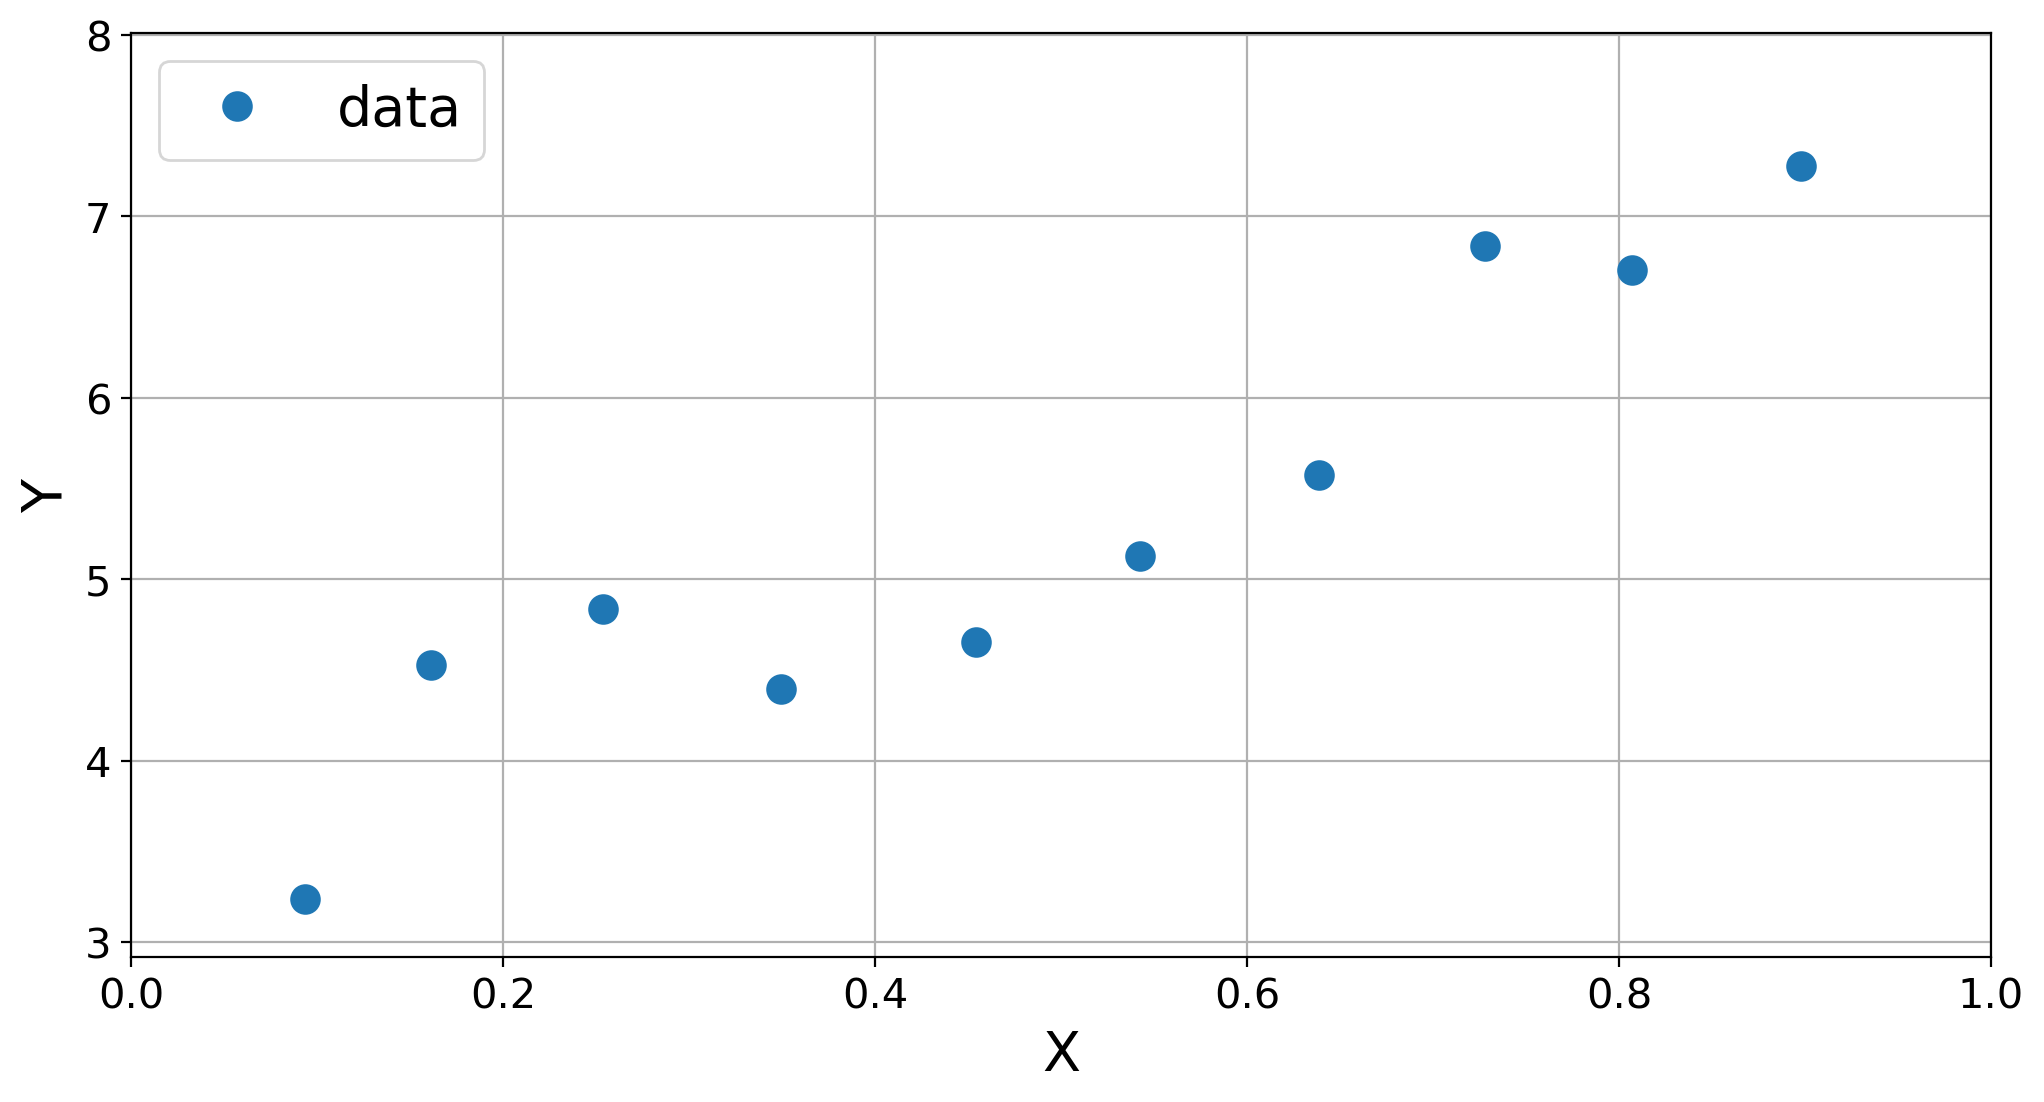

In [6]:
plot_res(X1, Y1)

In [7]:
random.seed(42)

noise = [1]*10 + [-1]*10
random.shuffle(noise)

X2 = np.array([.045*i + random.uniform(-0.02, 0.02) for i in range(1, 21)])
Y2 = np.array([random.uniform(.1, .8)*noise[i] for i in range(0, 20)])  # noise
Y2 += 4.2*X2
Y2 += np.pi

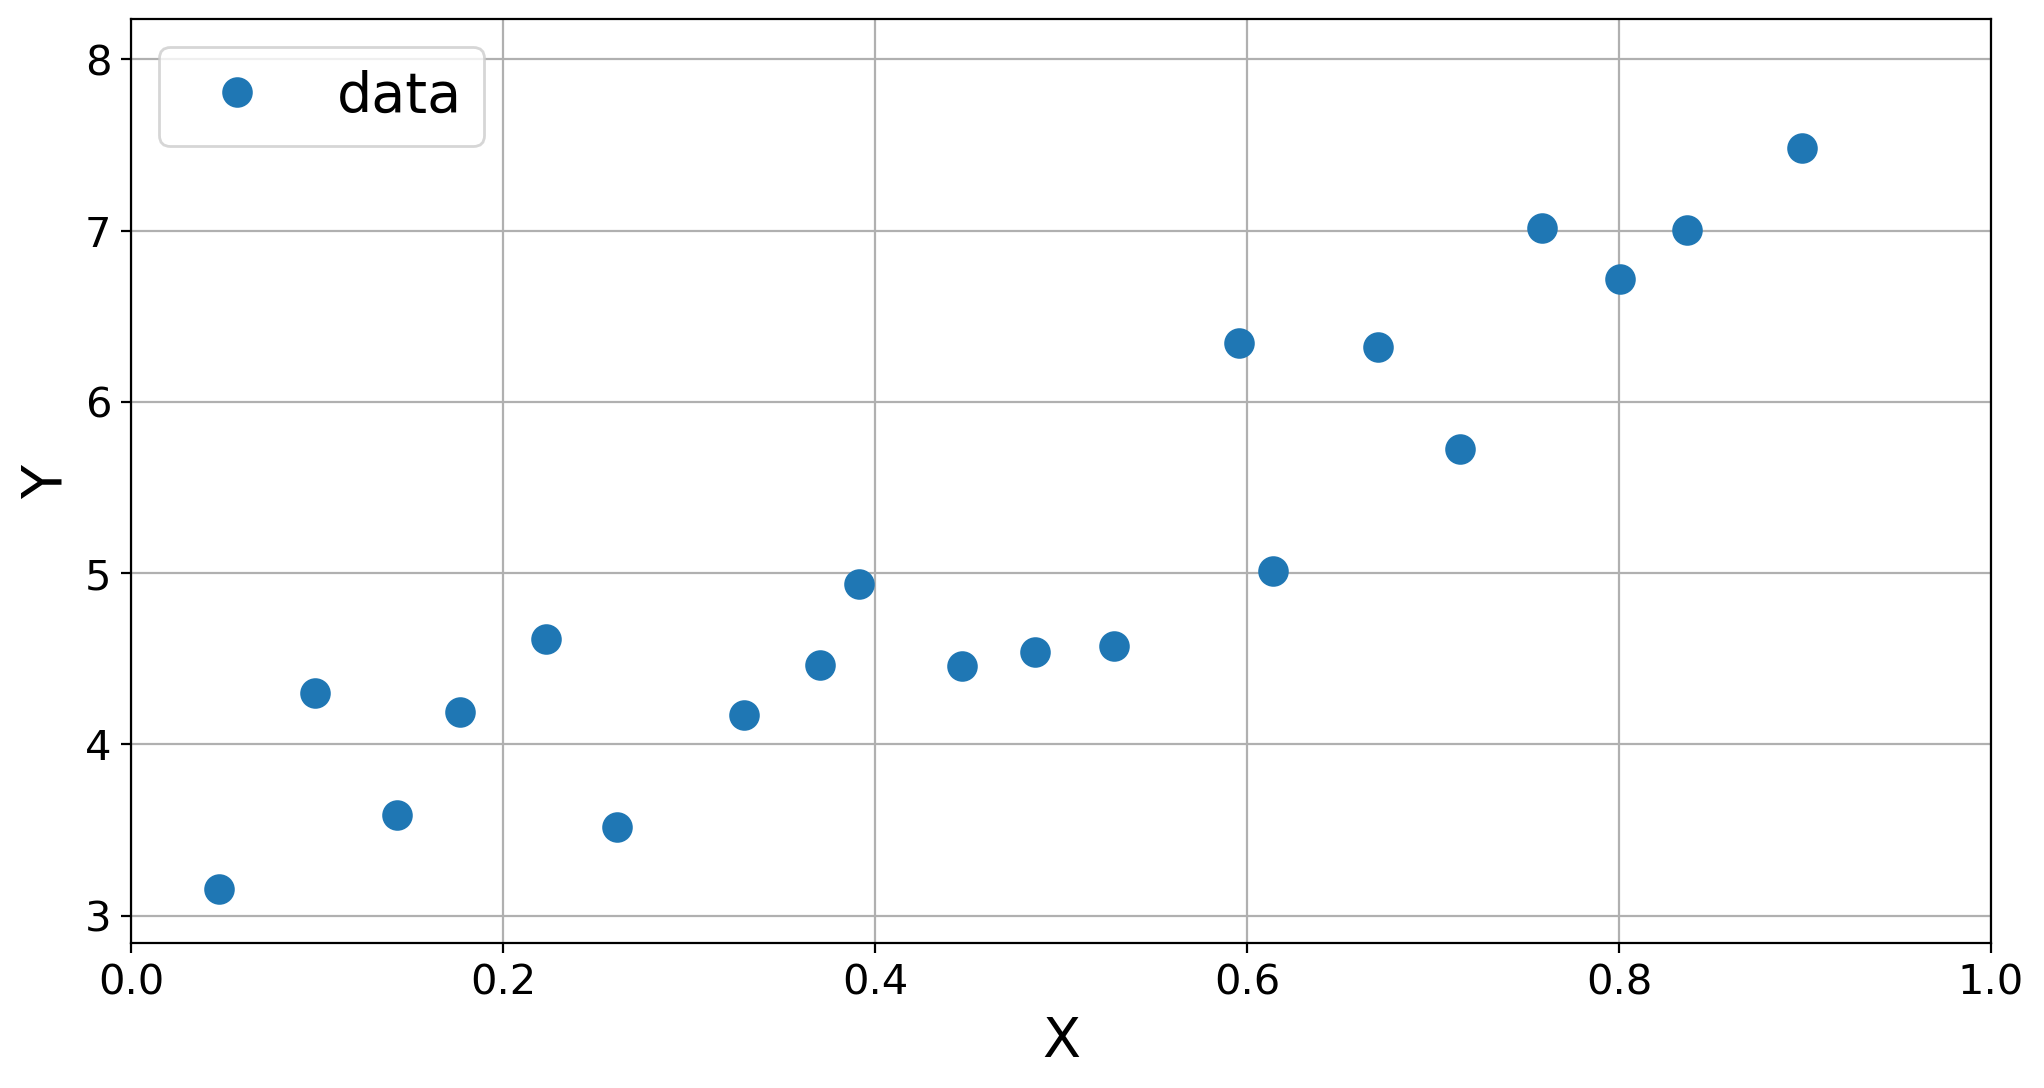

In [8]:
plot_res(X2, Y2)

## 2 Learning


### 2.1 Standard least squares


In [9]:
### arrange model f(x)
functions = [lambda x,n=n: x**n for n in range(20)]
func = functions[:2] # just a linear function

### calculate transformed data
xvec = []
for x in X1:
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)

xvec

array([[1.        , 0.0936197 ],
       [1.        , 0.16127131],
       [1.        , 0.25374781],
       [1.        , 0.34930644],
       [1.        , 0.45408075],
       [1.        , 0.5424498 ],
       [1.        , 0.63864078],
       [1.        , 0.728053  ],
       [1.        , 0.80678079],
       [1.        , 0.89796836]])

In [10]:
### setup of regression model
reg = LinearRegression()
reg.fit(xvec, Y1)

### check coefficients
print('coef:', reg.coef_)
print('intercept:', reg.intercept_)

coef: [0.         4.31301265]
intercept: 3.1923298291307796


**Note**: We can also include intercept within the coefficients. This depends also on the choice for xvec (if we include 1 as first entry or not).


In [11]:
### setup of regression model
reg = LinearRegression(fit_intercept=False) # new
reg.fit(xvec, Y1)

### check coefficients
print('coef:', reg.coef_)
print('intercept:', reg.intercept_)

coef: [3.19232983 4.31301265]
intercept: 0.0


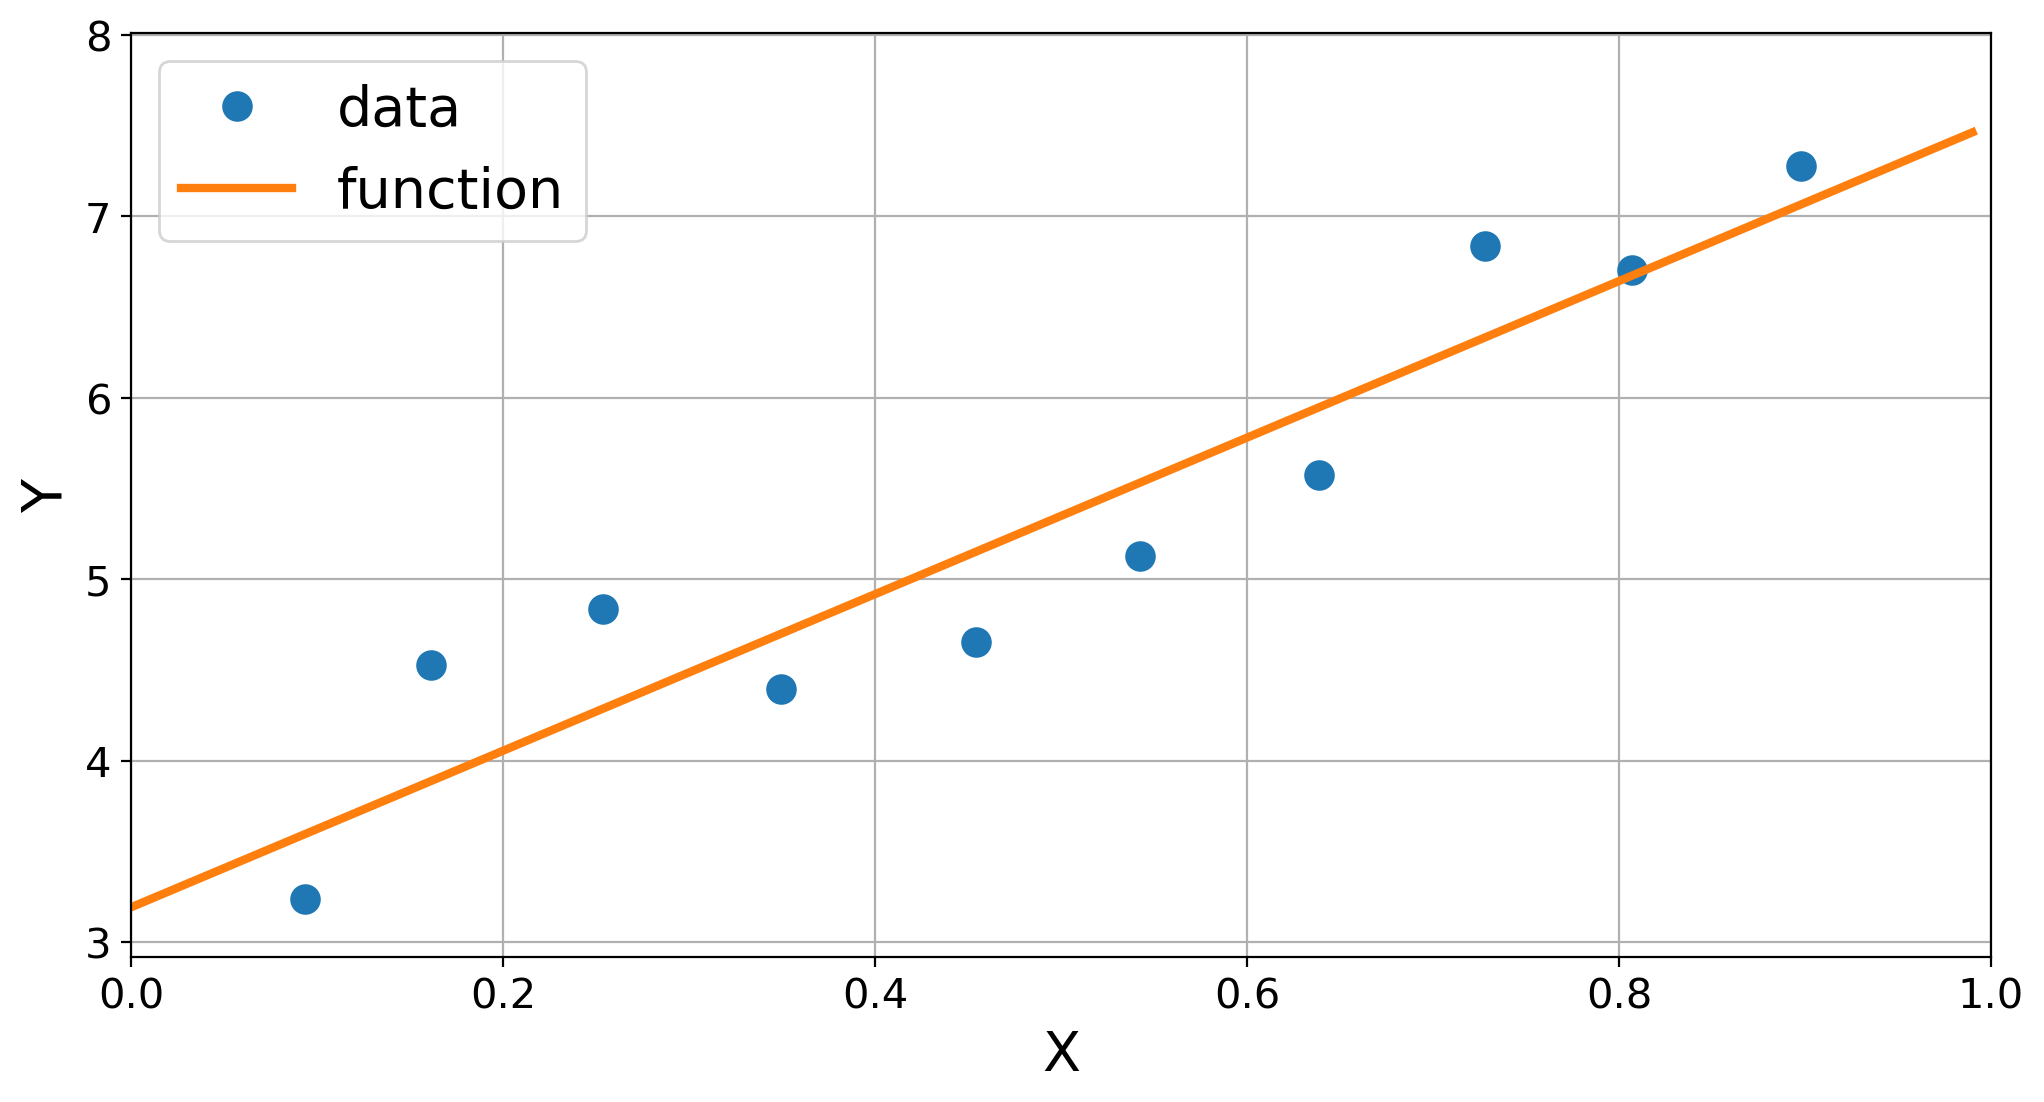

In [12]:
### plot data
plot_res_multi(X1, Y1, reg.coef_, func)

### Test more complex model


score: 1.0


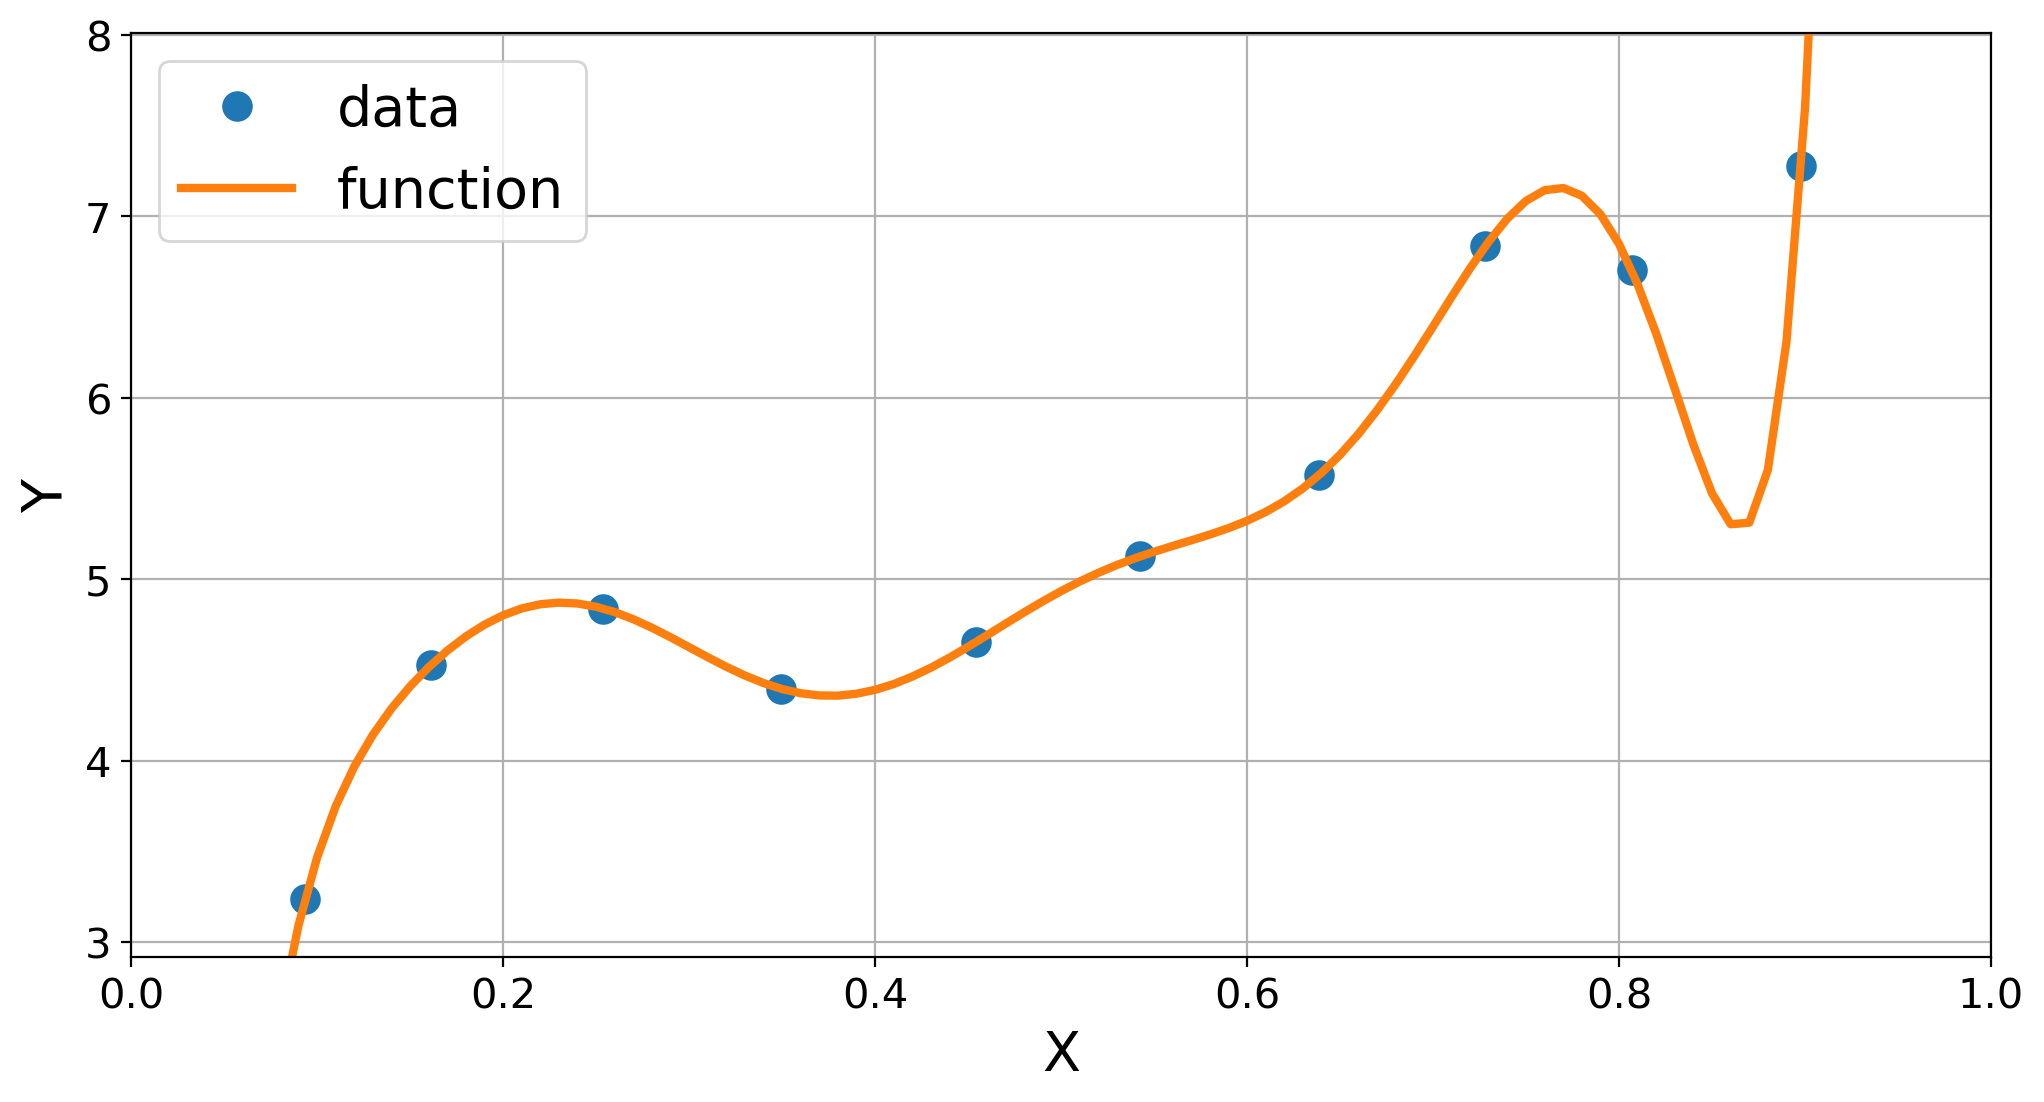

In [13]:
### arrange model f(x)
functions = [lambda x,n=n: x**n for n in range(20)] # n=0 leads to the needed first entry
func = functions[:10] # == multivariate case

### calculate transformed data
xvec = []
for x in X1:
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg = LinearRegression(fit_intercept=False) # new
reg.fit(xvec, Y1)
print("score:", reg.score(xvec, Y1))


### plot solution
plot_res_multi(X1, Y1, reg.coef_, func)

**Conclusion**: Perfect fit when number of functions fit number of data points.


### More points:


score: 0.9884135086728393


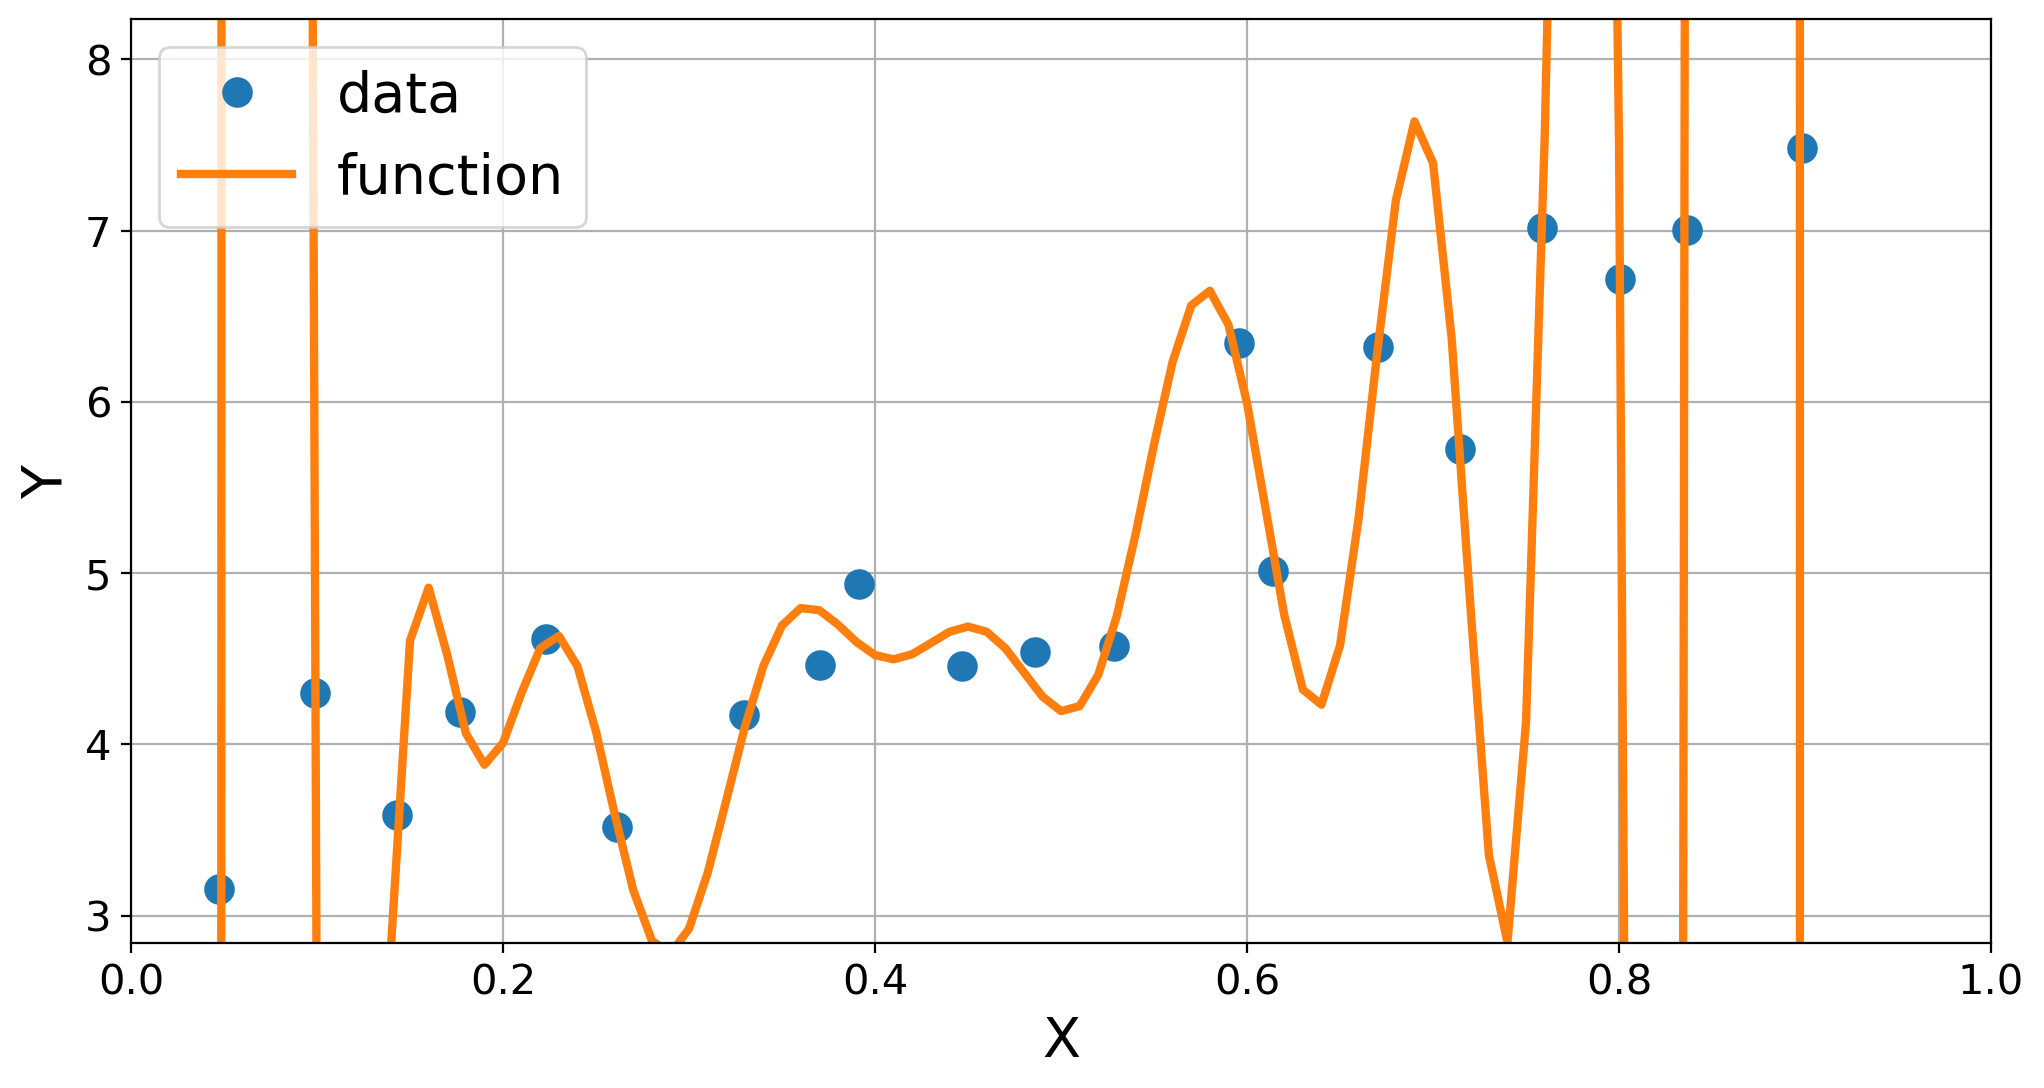

In [14]:
### arrange model f(x)
functions = [lambda x,n=n: x**n for n in range(21)] # n=0 leads to the needed first entry
func = functions[:21] # new

### calculate transformed data
xvec = []
for x in X2:# new
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg = LinearRegression(fit_intercept=False) # new
reg.fit(xvec, Y2)
print("score:", reg.score(xvec, Y2))


### plot solution
plot_res_multi(X2, Y2, reg.coef_, func)

In [15]:
### check coefficients
print(reg.coef_)

[-3.26684496e+04  2.35249756e+06 -7.31290557e+07  1.32155911e+09
 -1.56788916e+10  1.30208369e+11 -7.85320399e+11  3.50984859e+12
 -1.17062261e+13  2.89277413e+13 -5.14131614e+13  6.03846469e+13
 -3.32127853e+13 -2.22009346e+13  5.53456574e+13 -2.63448474e+13
 -3.54691401e+13  6.56766813e+13 -4.77099933e+13  1.76081760e+13
 -2.72612986e+12]


**Conclusion**: Even for the exact formula we get deviations due to numerical errors due to large coeffecients.


### Using some other functions:


score: 1.0


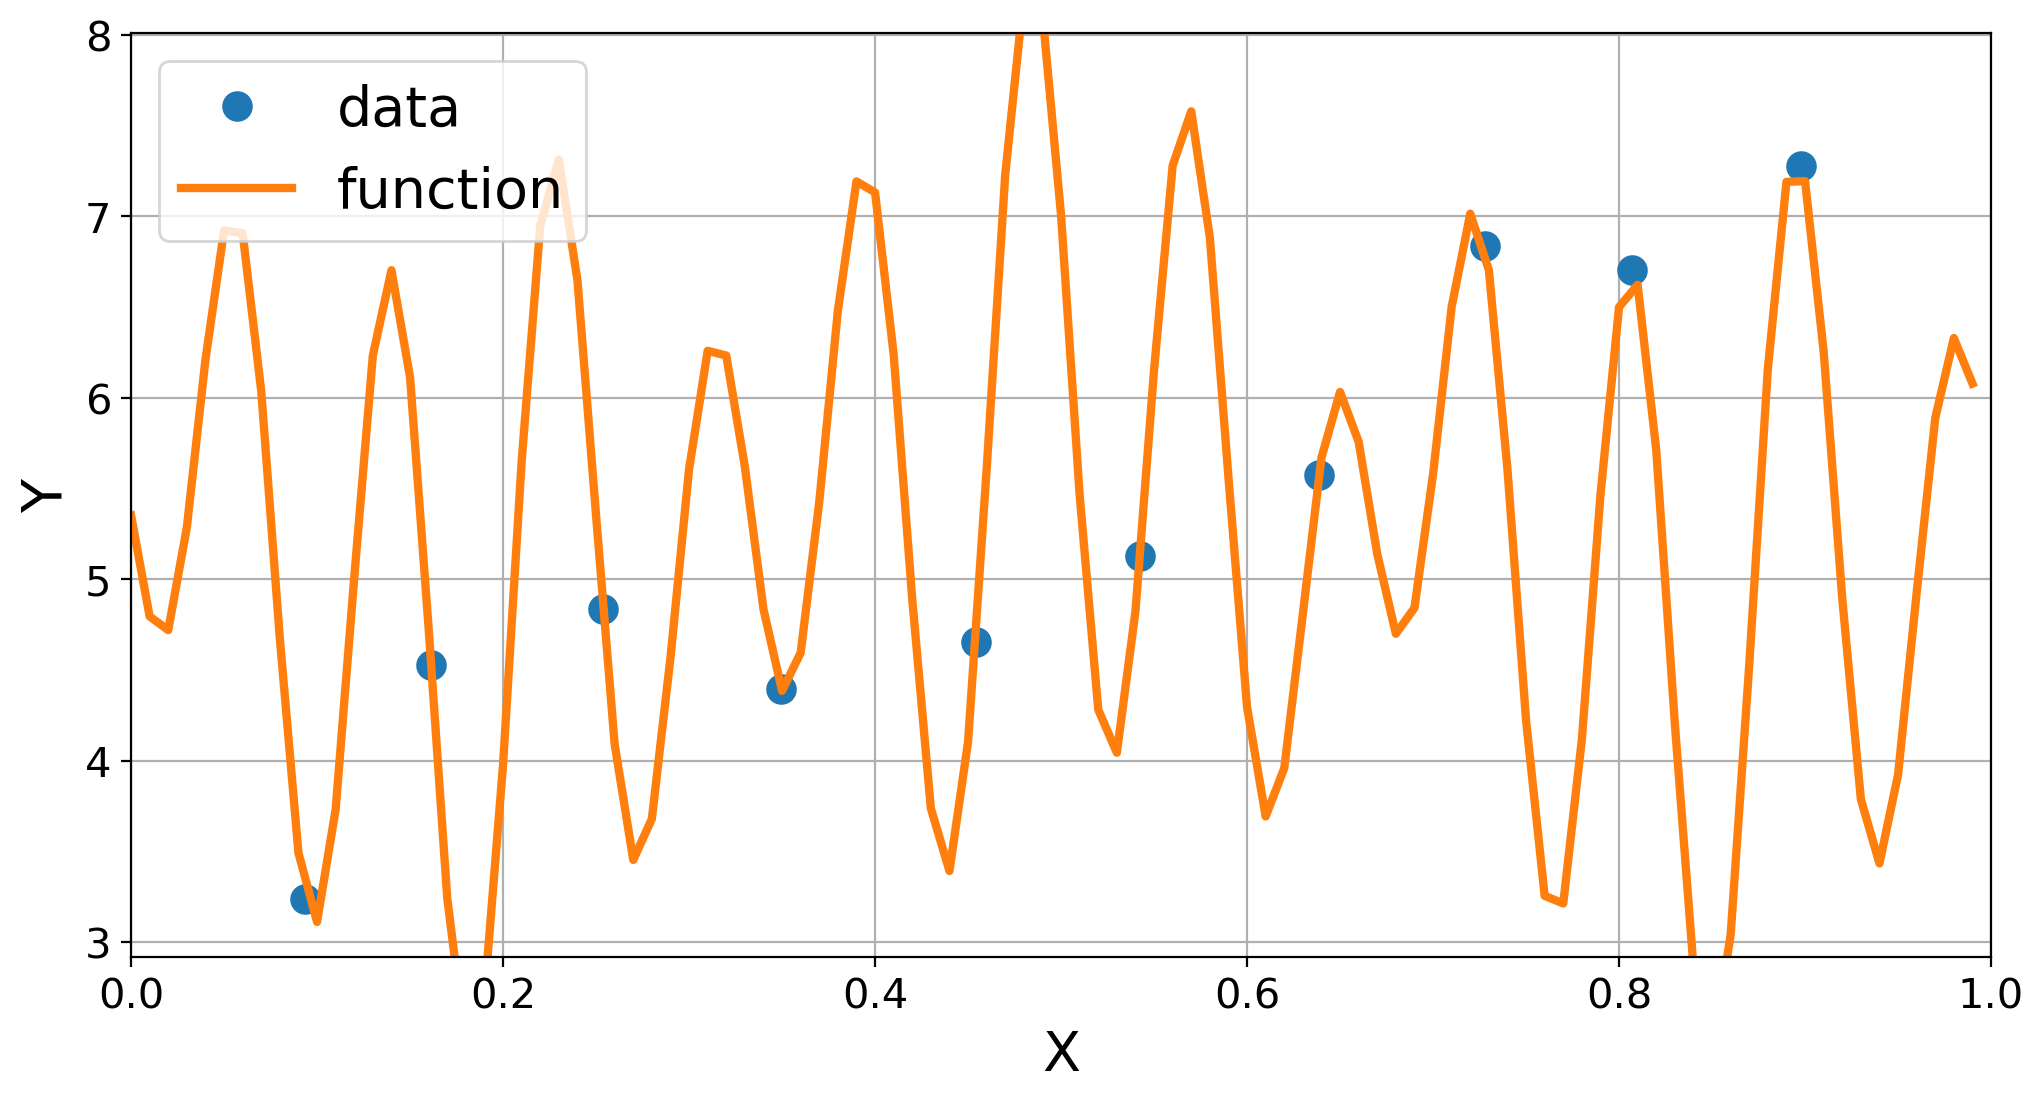

In [16]:
### arrange model f(x)
functions = [lambda x: 1] + [lambda x, n=n: np.sin(3*np.pi*n*x) for n in range(1, 20)] # new
func = functions[:10] # == multivariate case

### calculate transformed data
xvec = []
for x in X1:
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg = LinearRegression(fit_intercept=False) # new
reg.fit(xvec, Y1)
print("score:", reg.score(xvec, Y1))


### plot solution
plot_res_multi(X1, Y1, reg.coef_, func)

score: 1.0


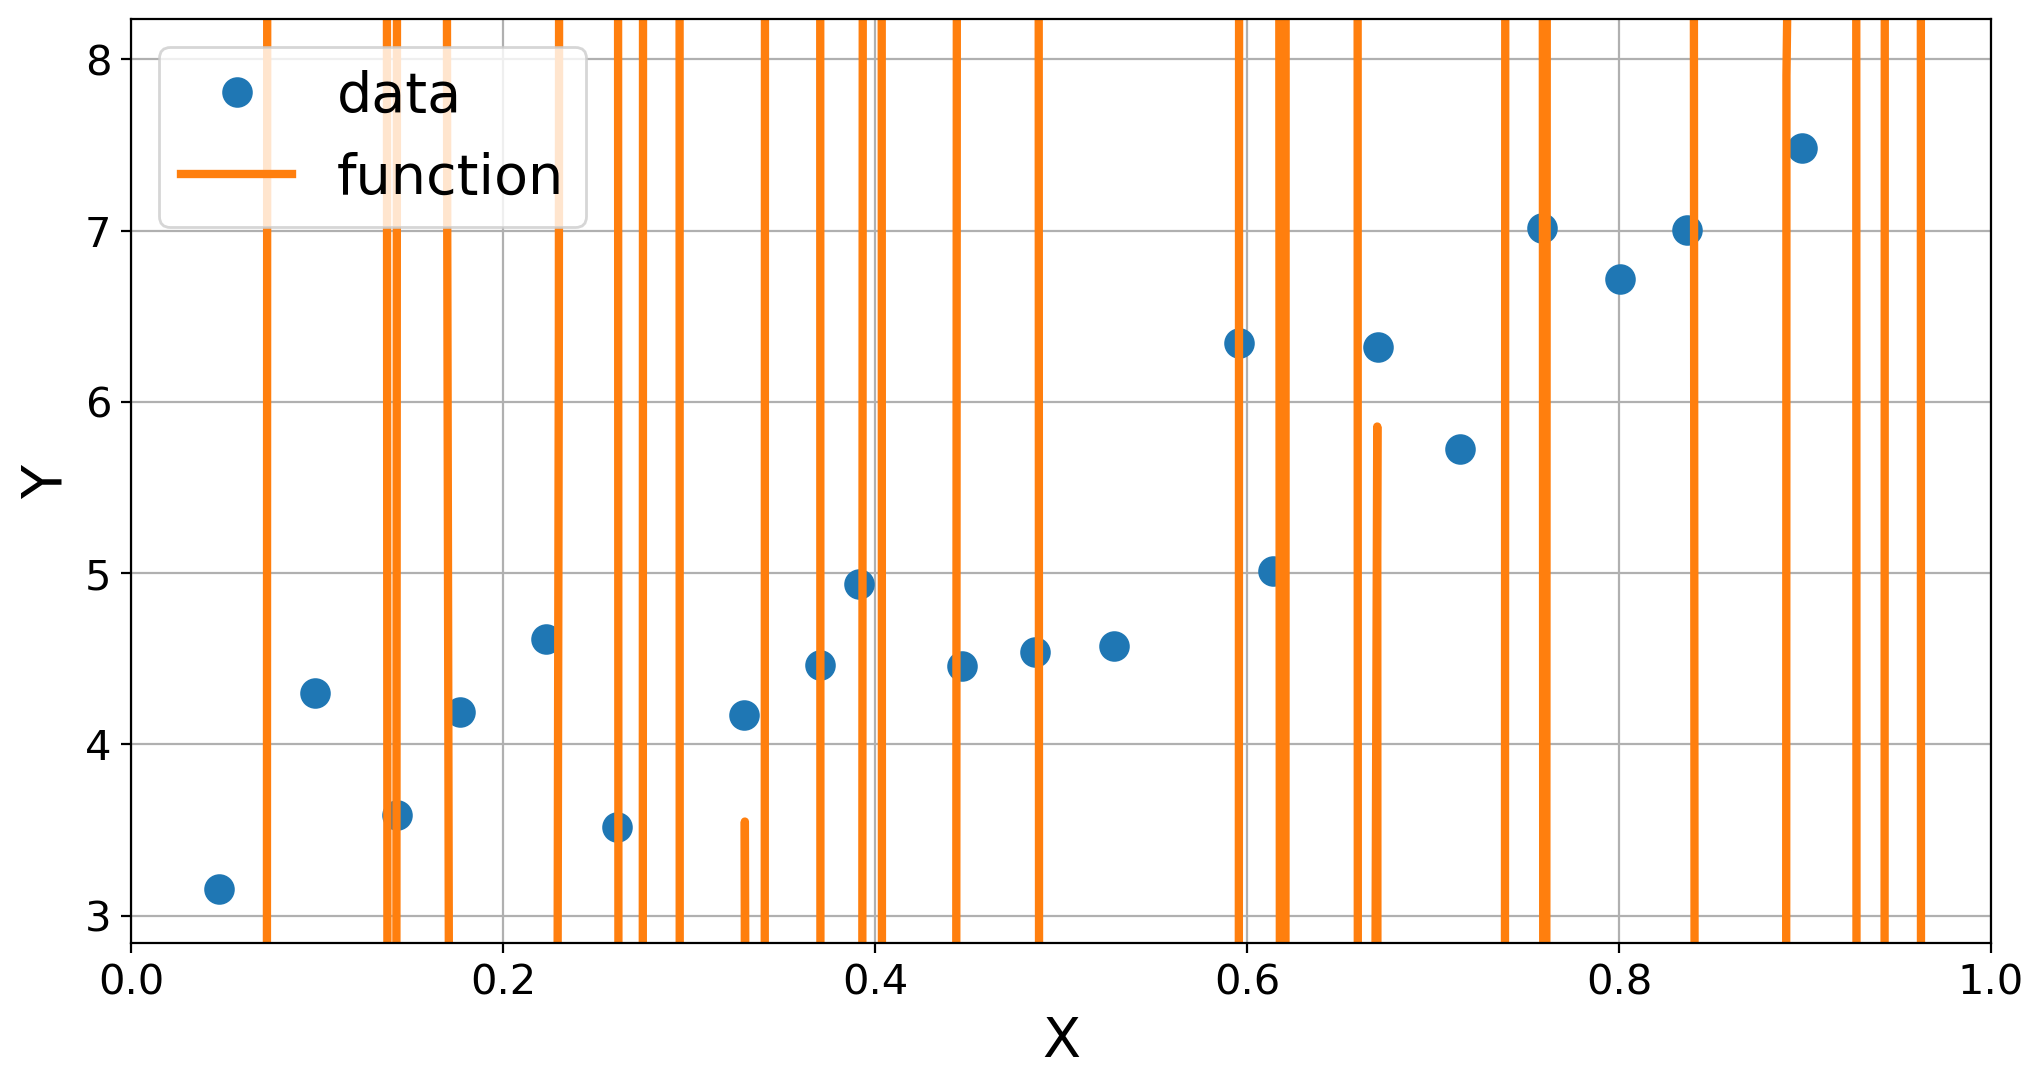

In [17]:
### arrange model f(x)
functions = [lambda x: 1] + [lambda x, n=n: np.sin(3*np.pi*n*x) for n in range(1, 20)] # new
func = functions[:20] # new

### calculate transformed data
xvec = []
for x in X2:
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg = LinearRegression(fit_intercept=False) # new
reg.fit(xvec, Y2)
print("score:", reg.score(xvec, Y2))


### plot solution
plot_res_multi(X2, Y2, reg.coef_, func)

In [18]:
print(reg.coef_)

[ -25.27286585  -14.53153094   59.98925538  -68.25858407 -306.20971714
 -286.6773206    81.64235022 -210.88534839  -43.13333578  -56.88610391
  -60.7431771  -213.37212272  125.68545889   26.08353904    7.61347871
   -4.51006506  -11.28774777  127.43024142   10.99628887  253.83127227]


**Conclusion**: This works exact, because the coefficients are comparable in size.


### 2.2 Huber Regression


score: 0.9542124843024093


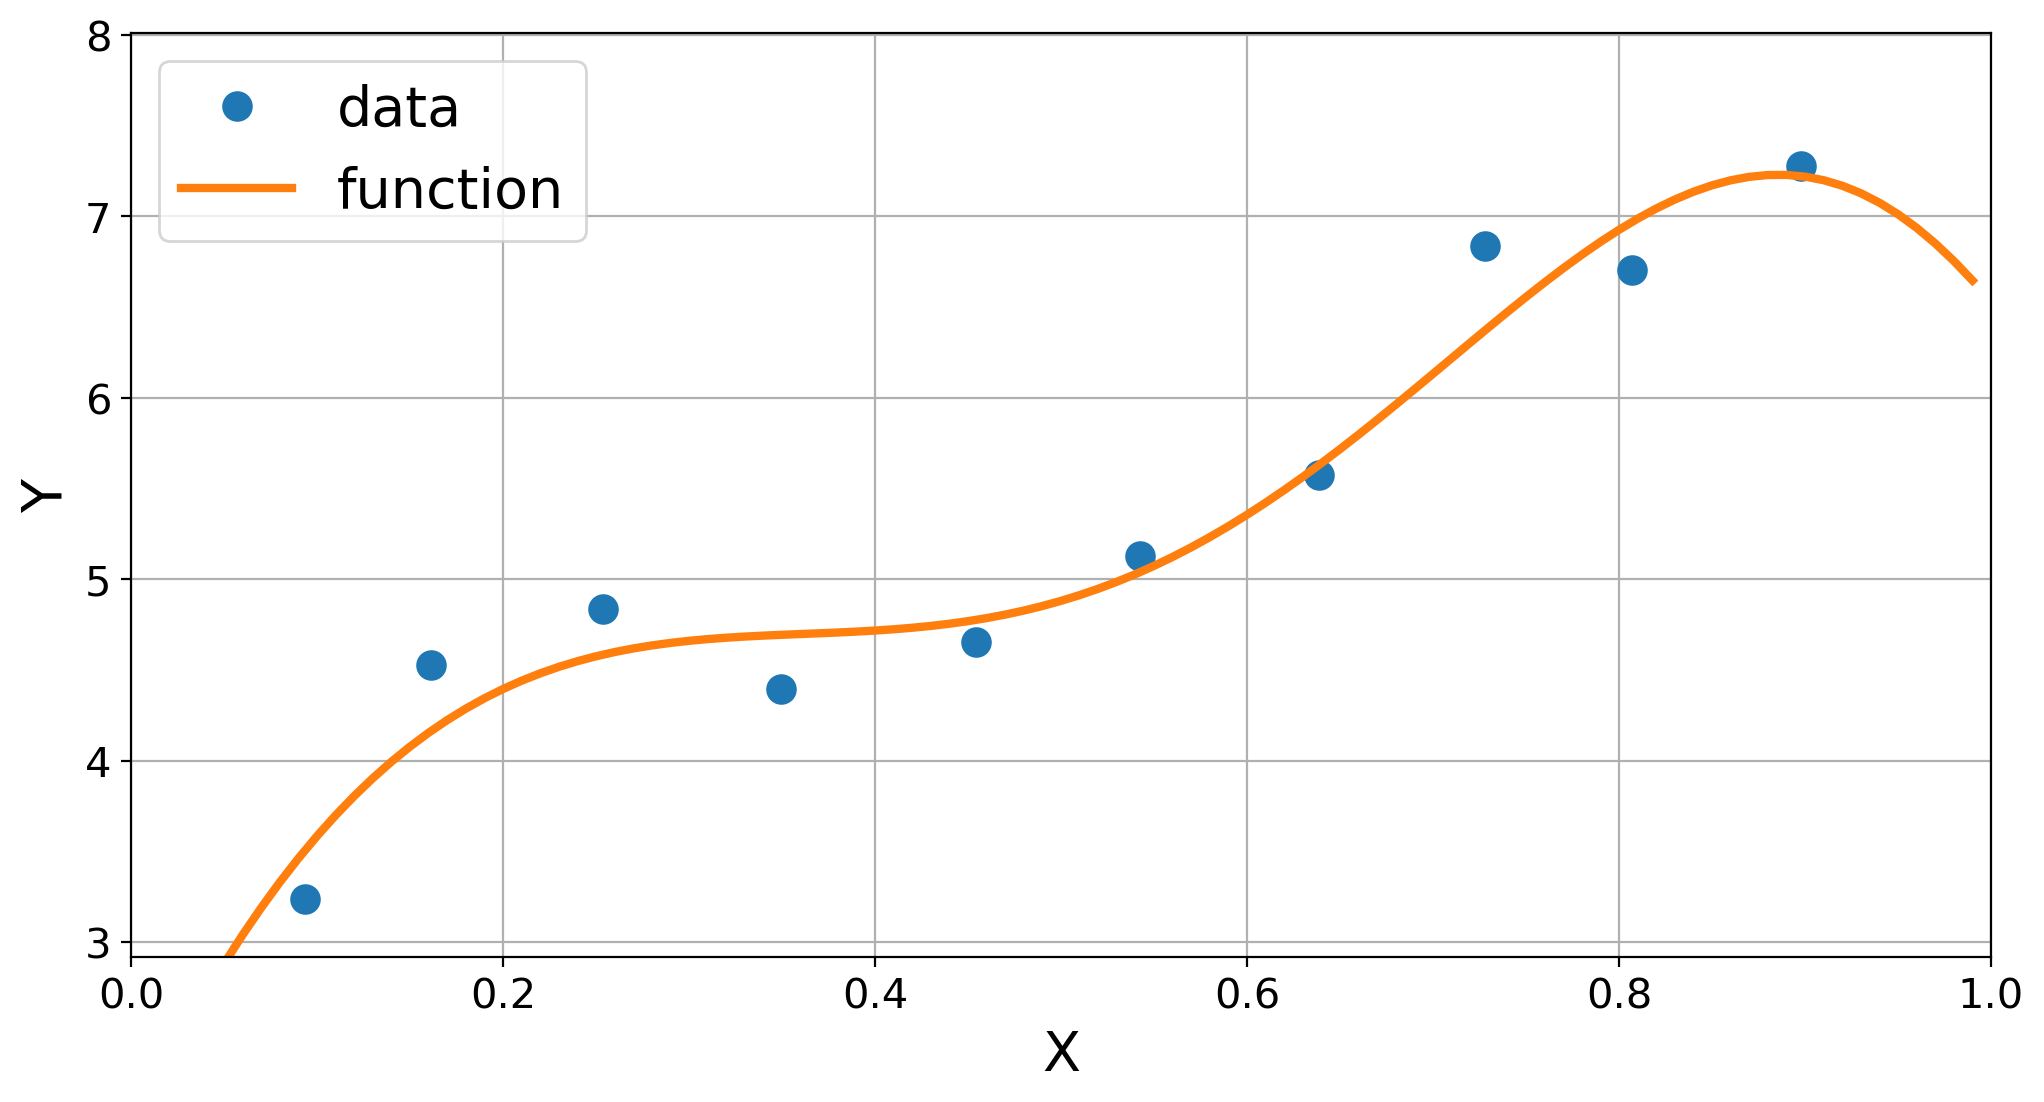

In [19]:
### arrange model f(x)
functions = [lambda x,n=n: x**n for n in range(20)] # n=0 leads to the needed first entry
func = functions[:10]

### calculate transformed data
xvec = []
for x in X1:
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg_huber = HuberRegressor(fit_intercept=False) # new
reg_huber.fit(xvec, Y1)
print("score:", reg_huber.score(xvec, Y1))


### plot solution
plot_res_multi(X1, Y1, reg_huber.coef_, func)

### Changing epsilon:


In [20]:
# help(HuberRegressor)

score: 0.9546231773789173


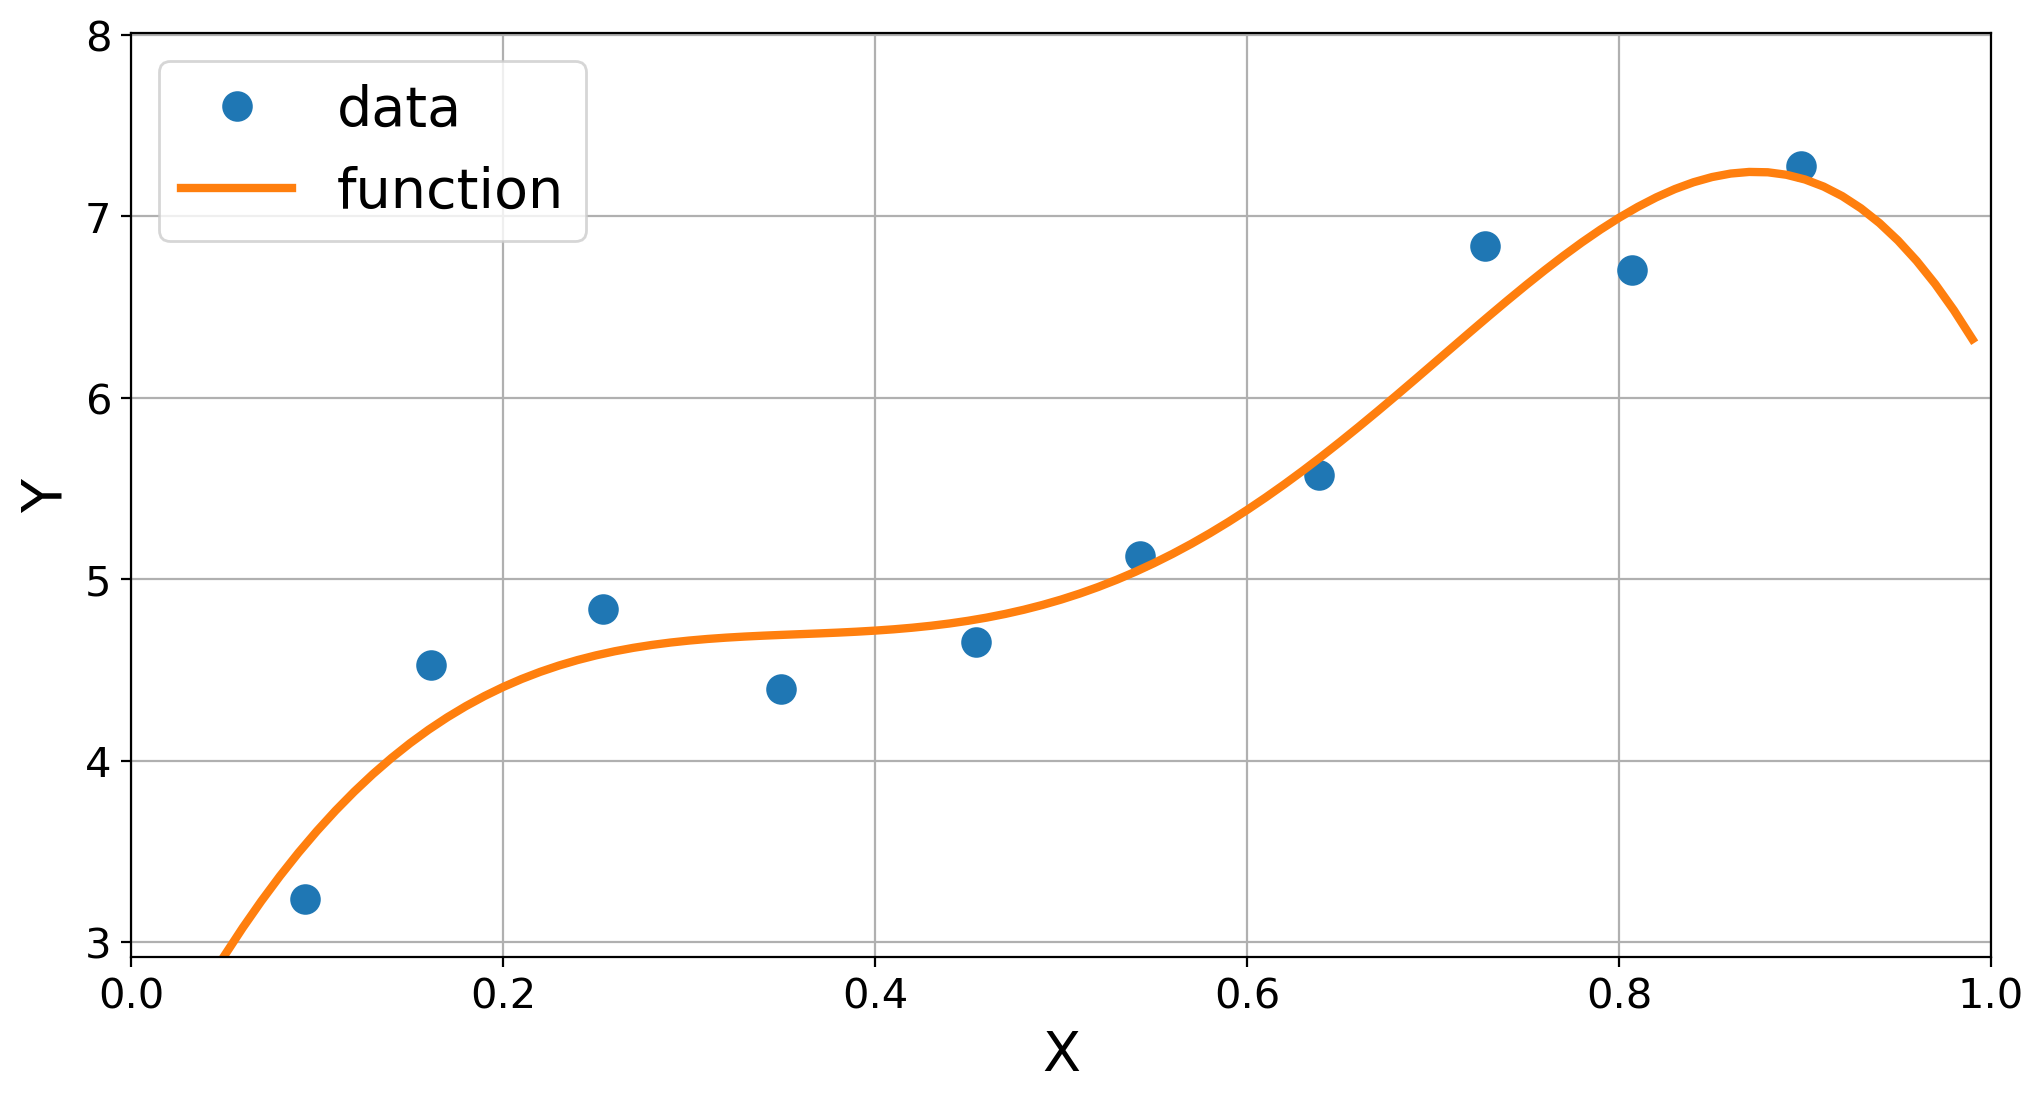

In [21]:
### arrange model f(x)
functions = [lambda x,n=n: x**n for n in range(20)] # n=0 leads to the needed first entry
func = functions[:10]

### calculate transformed data
xvec = []
for x in X1:
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg_huber = HuberRegressor(fit_intercept=False, epsilon=10.0) # new
reg_huber.fit(xvec, Y1)
print("score:", reg_huber.score(xvec, Y1))


### plot solution
plot_res_multi(X1, Y1, reg_huber.coef_, func)

**Conclusion**: Due to the $L_1$ contribution the Huber Regressor works with a numeric solution and thus has similar issues as our simple gradient descent algorithm.


### less points:


/opt/conda/envs/learn-ai-1/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


score: 0.999999999999978


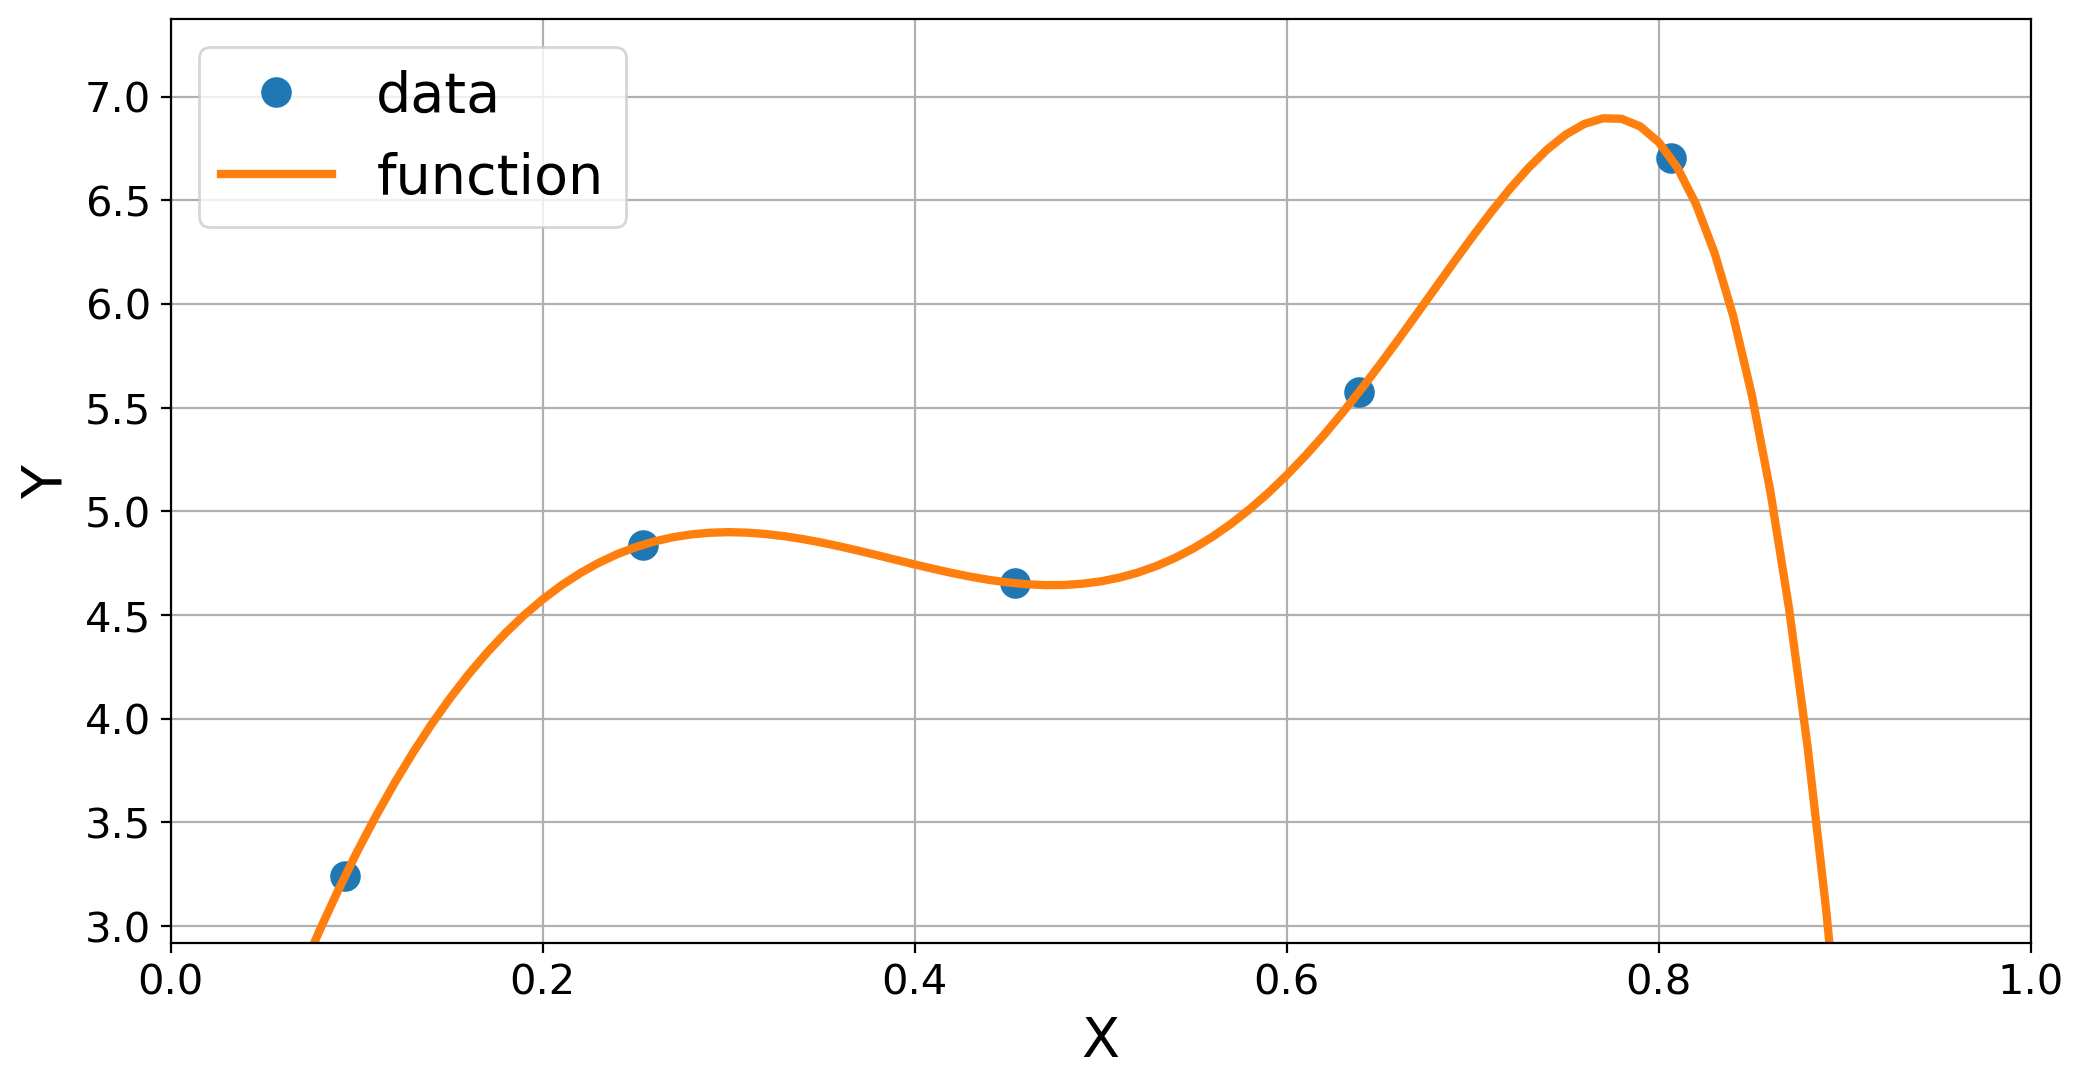

In [22]:
### consider every second data point
mapping = [True, False] * int(len(X1)/2)
# print(mapping)

### arrange model f(x)
functions = [lambda x,n=n: x**n for n in range(20)]
func = functions[:10]

### calculate transformed data
xvec = []
for x in X1[mapping]: # new
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg_huber = HuberRegressor(fit_intercept=False, epsilon=10.0) # new
reg_huber.fit(xvec, Y1[mapping])
print("score:", reg_huber.score(xvec, Y1[mapping]))


### plot solution
plot_res_multi(X1[mapping], Y1[mapping], reg_huber.coef_, func)

score: 0.9999999976374258


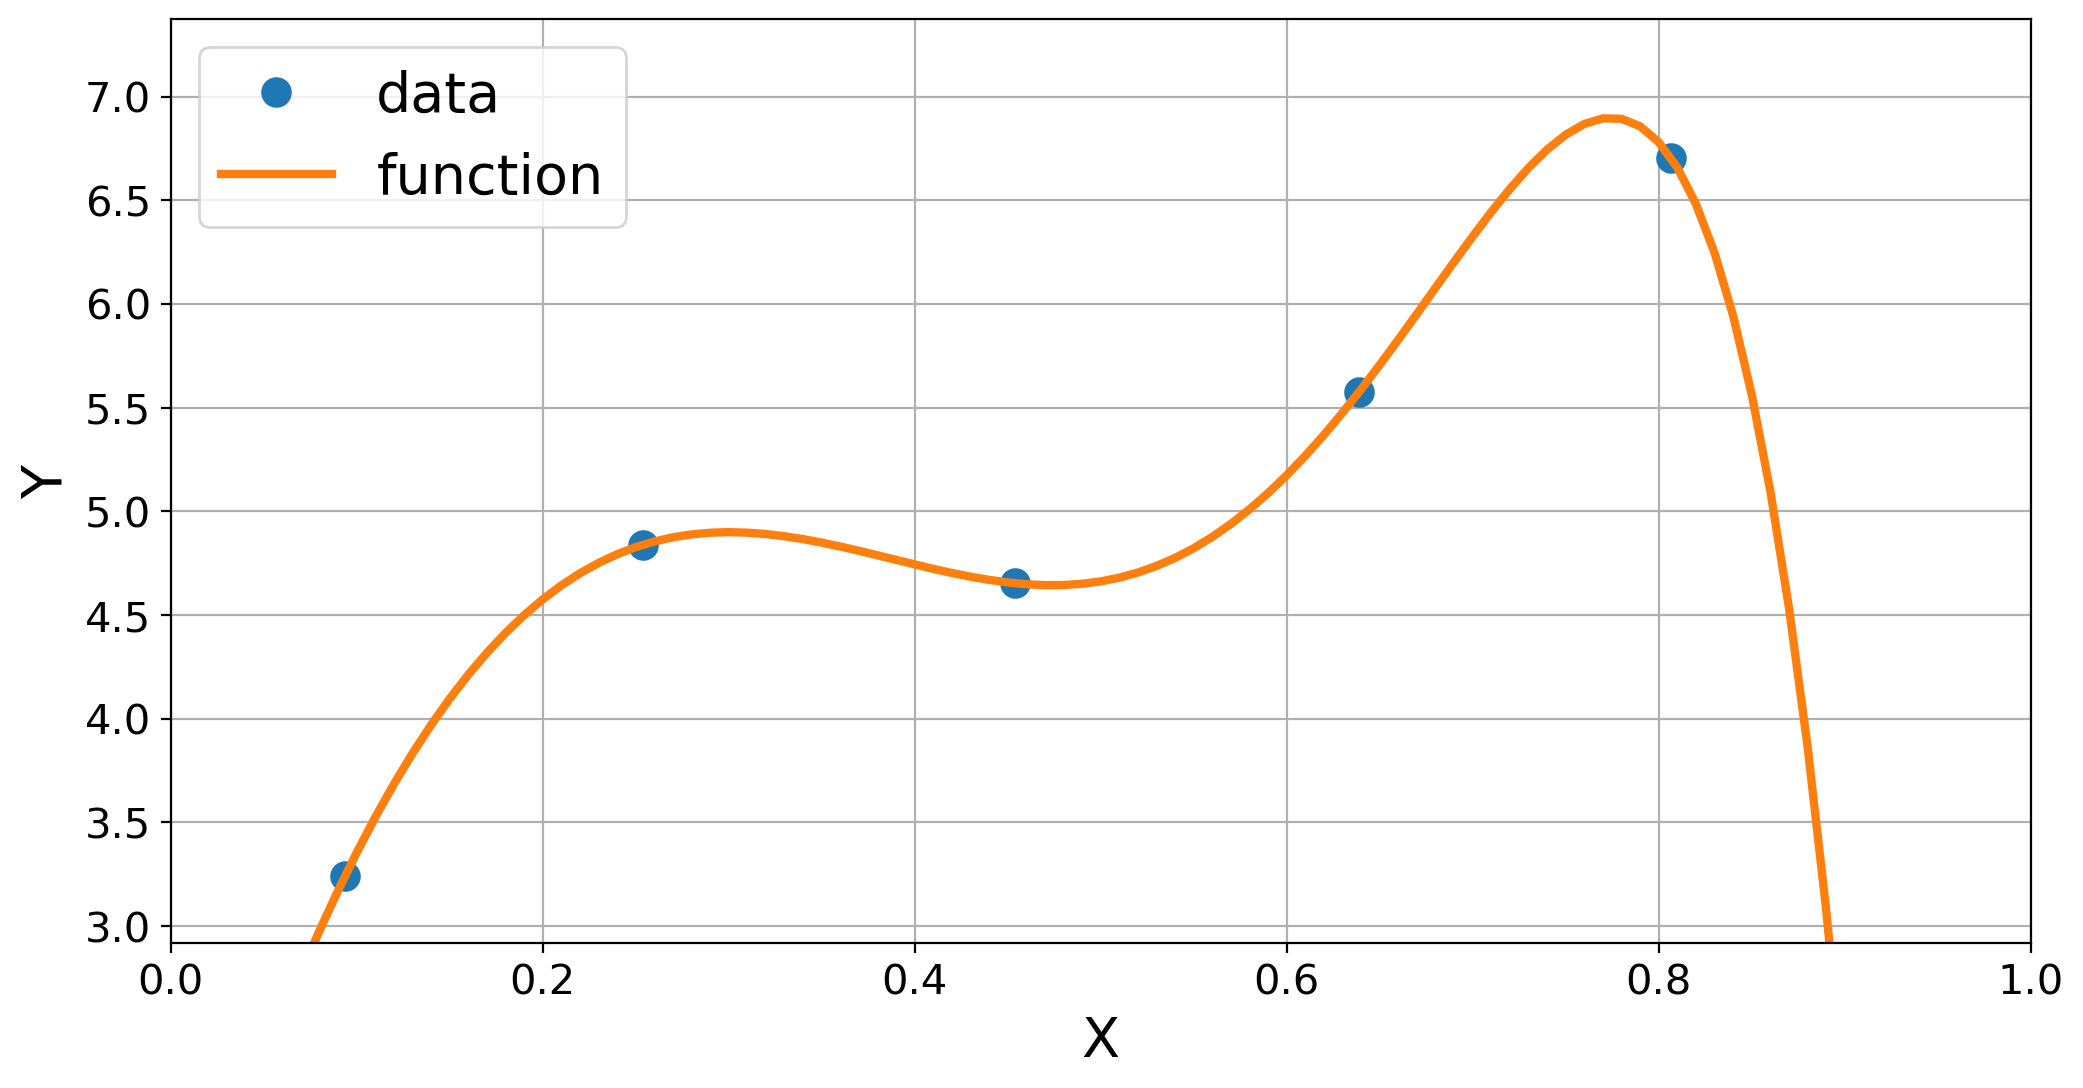

In [23]:
### consider every second data point
mapping = [True, False] * int(len(X1)/2)
# print(mapping)

### arrange model f(x)
functions = [lambda x,n=n: x**n for n in range(20)]
func = functions[:10]

### calculate transformed data
xvec = []
for x in X1[mapping]: # new
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg_huber = HuberRegressor(fit_intercept=False, epsilon=3.0) # new
reg_huber.fit(xvec, Y1[mapping])
print("score:", reg_huber.score(xvec, Y1[mapping]))


### plot solution
plot_res_multi(X1[mapping], Y1[mapping], reg_huber.coef_, func)

### Other functions:


/opt/conda/envs/learn-ai-1/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


score: 1.0


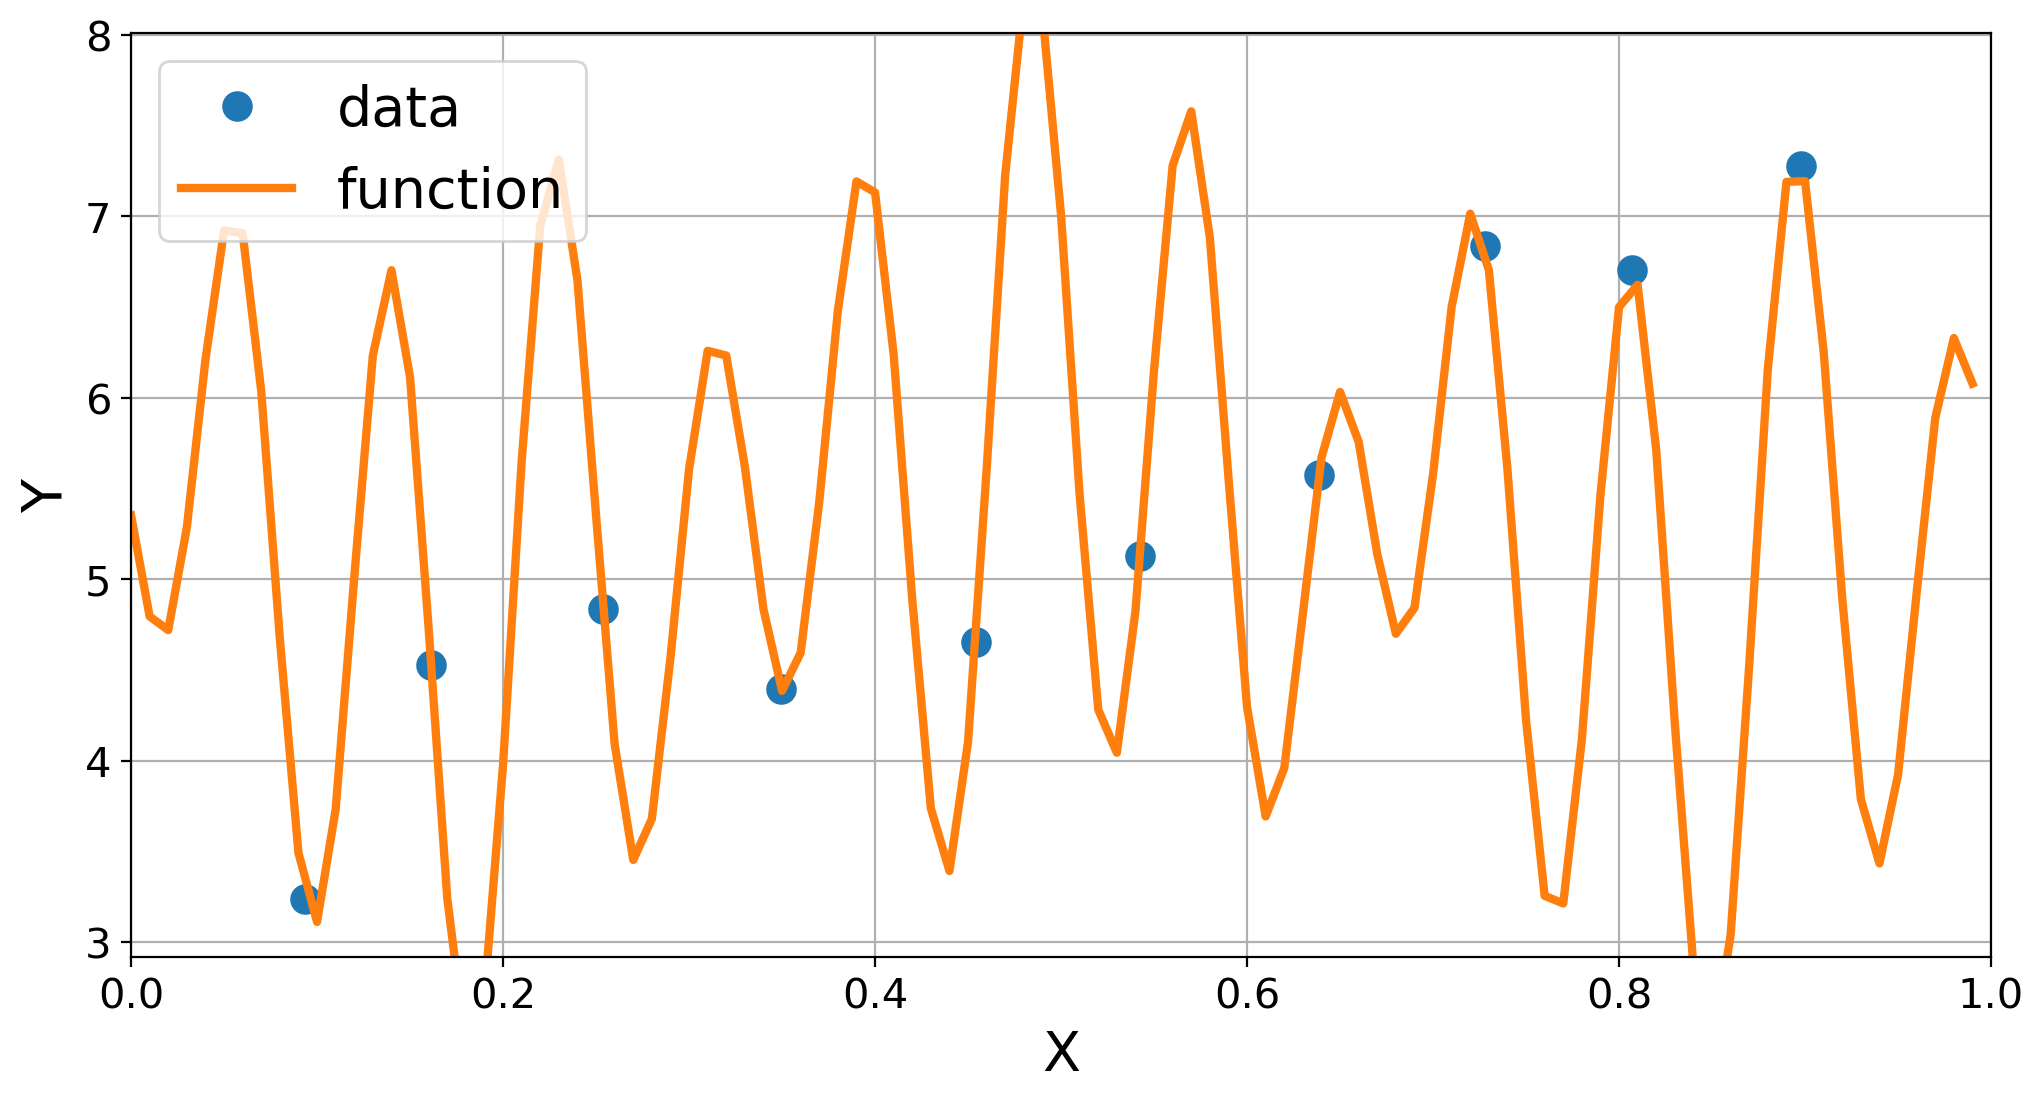

In [24]:
### arrange model f(x)
functions = [lambda x: 1] + [lambda x, n=n: np.sin(3*np.pi*n*x) for n in range(1, 20)] # new
func = functions[:10] # == multivariate case

### calculate transformed data
xvec = []
for x in X1:
    xvec.append([f(x) for f in func])
xvec = np.array(xvec)


### calculate weights via regression
reg_huber = HuberRegressor(fit_intercept=False)
reg_huber.fit(xvec, Y1)
print("score:", reg_huber.score(xvec, Y1))


### plot solution
plot_res_multi(X1, Y1, reg_huber.coef_, func)